In [1]:
import sys
import os
# sys.path.append('../')
# sys.path.append('../modules/')
# sys.path.append('../util/')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import random
from SFM_Finetune import models_Segmentation, models_Regression
from modules.modeling.deeplab import *
from modules.modeling.Unet_models import *
from util.metrics import *

## data visualization

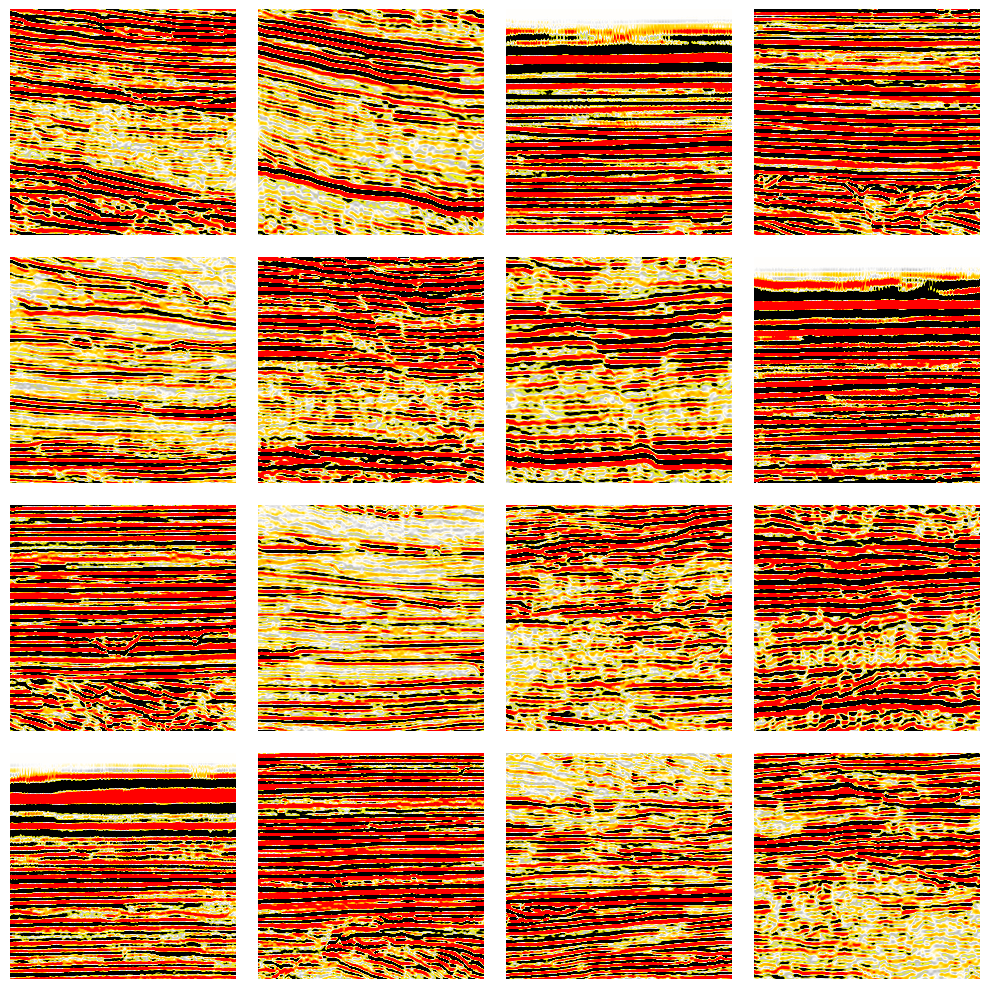

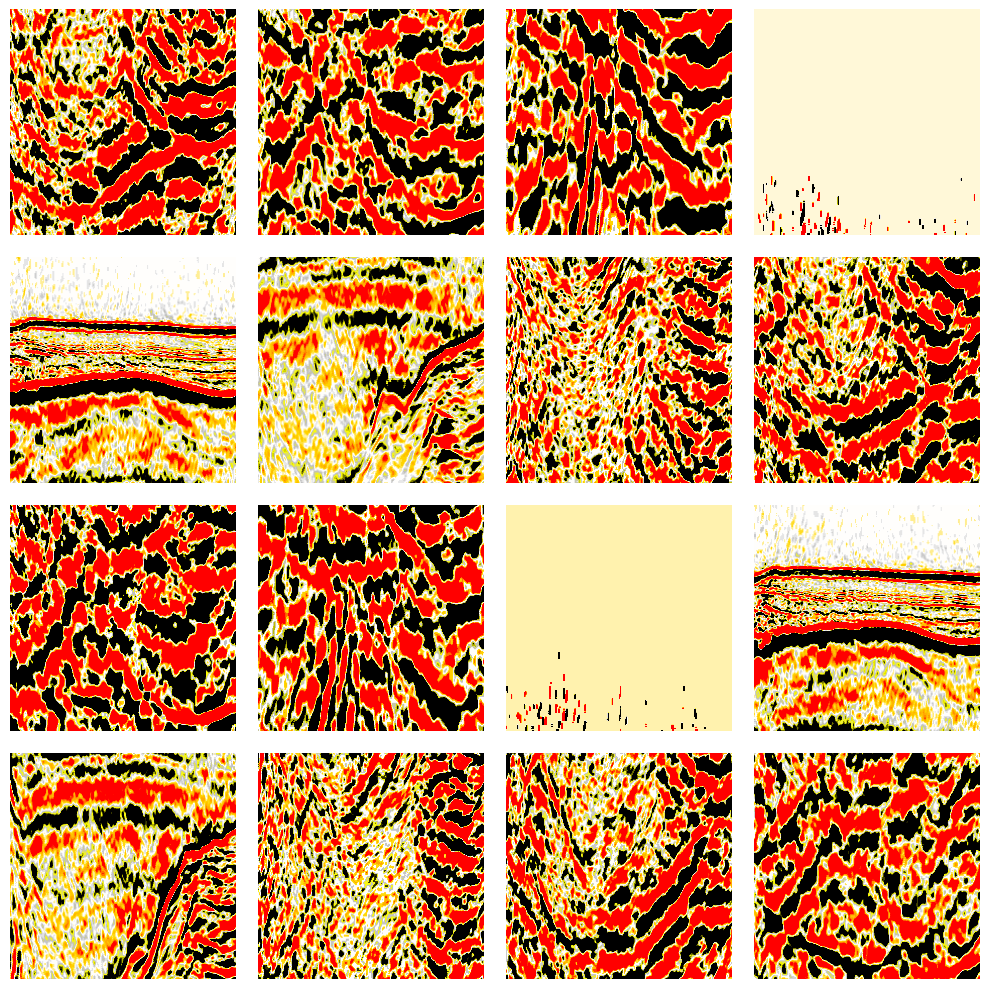

In [2]:
color_list = ['black','yellow','silver','white','gold','orange','red']
cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)

data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Interpolation/'
data_files =  [str(f)+'.dat' for f in range(2000, 2017)]
selected_files = data_files
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    with open(os.path.join(data_path, selected_files[i]), 'rb') as f:
        data = np.fromfile(f, dtype=np.single)
        img_size = int(np.sqrt(data.size))
        data = data.reshape((img_size, img_size))
        ax.imshow(data, cmap=cmap,vmin=np.min(data)/10,vmax=-np.min(data)/10)
        ax.axis('off')
# 显示整个图像
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Interpolation/'
data_files =  ['U'+str(f)+'.dat' for f in range(2000, 2017)]
selected_files = data_files
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    with open(os.path.join(data_path, selected_files[i]), 'rb') as f:
        data = np.fromfile(f, dtype=np.single)
        img_size = int(np.sqrt(data.size))
        data = data.reshape((img_size, img_size))
        ax.imshow(data, cmap=cmap,vmin=np.min(data)/10,vmax=-np.min(data)/10)
        ax.axis('off')
# 显示整个图像
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

## load Model

In [3]:
def prepare_model(chkpt_dir, arch='vit_base_patch16', img_size=224):
    # 检查是否有可用的GPU
    if torch.cuda.is_available():
        # 获取GPU的数量
        num_gpus = torch.cuda.device_count()
        print(f"Number of GPUs available: {num_gpus}")
    
        # 遍历每个GPU并打印详细信息
        for i in range(num_gpus):
            print(f"GPU {i} details:")
            # 获取GPU的名称
            gpu_name = torch.cuda.get_device_name(i)
            print(f"  Name: {gpu_name}")
            # 获取GPU的计算能力
            gpu_capability = torch.cuda.get_device_capability(i)
            print(f"  Compute Capability: {gpu_capability[0]}.{gpu_capability[1]}")
            # 获取GPU的显存总量
            gpu_memory = torch.cuda.get_device_properties(i).total_memory
            print(f"  Total Memory: {gpu_memory / 1e9:.2f} GB")
            # 获取GPU的当前占用显存
            gpu_current_memory = torch.cuda.memory_allocated(i)
            print(f"  Current Memory Allocated: {gpu_current_memory / 1e9:.2f} GB")
            # 获取GPU的当前缓存显存
            gpu_cached_memory = torch.cuda.memory_reserved(i)
            print(f"  Current Memory Cached: {gpu_cached_memory / 1e9:.2f} GB")

        # 选择内存使用量最小的显卡
        num_gpus = torch.cuda.device_count()
        min_memory_usage = float('inf')
        selected_gpu = None    
        for i in range(num_gpus):
            memory_allocated = torch.cuda.memory_allocated(i)
            if memory_allocated < min_memory_usage:
                min_memory_usage = memory_allocated
                selected_gpu = i
        print("GPU %d is selected." % selected_gpu)
        device = torch.device(f'cuda:{selected_gpu}')
    else:
        print("No GPU available.")
        device = torch.device('cpu')

    model = getattr(models_Regression, arch)(img_size=img_size,
                                             num_classes=1,
                                             drop_path_rate=0.1,
                                             in_chans=1,
                                             Interpolation=True)                                            
    checkpoint = torch.load(chkpt_dir, map_location=device)
#     interpolate_pos_embed(model, checkpoint['model'])
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    model.to(device)
    return model 

In [4]:
#load model
chkpt_dir = '/home/zhangji/LLM/Geophysics/output_dir/train_base_A100/finetune_checkpoint-1599/Interpolation/checkpoint-50.pth' 
model_SFM = prepare_model(chkpt_dir, 'vit_base_patch16', img_size=224)

Number of GPUs available: 2
GPU 0 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 1 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 0 is selected.
<All keys matched successfully>


In [5]:
print(model_SFM)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

3538


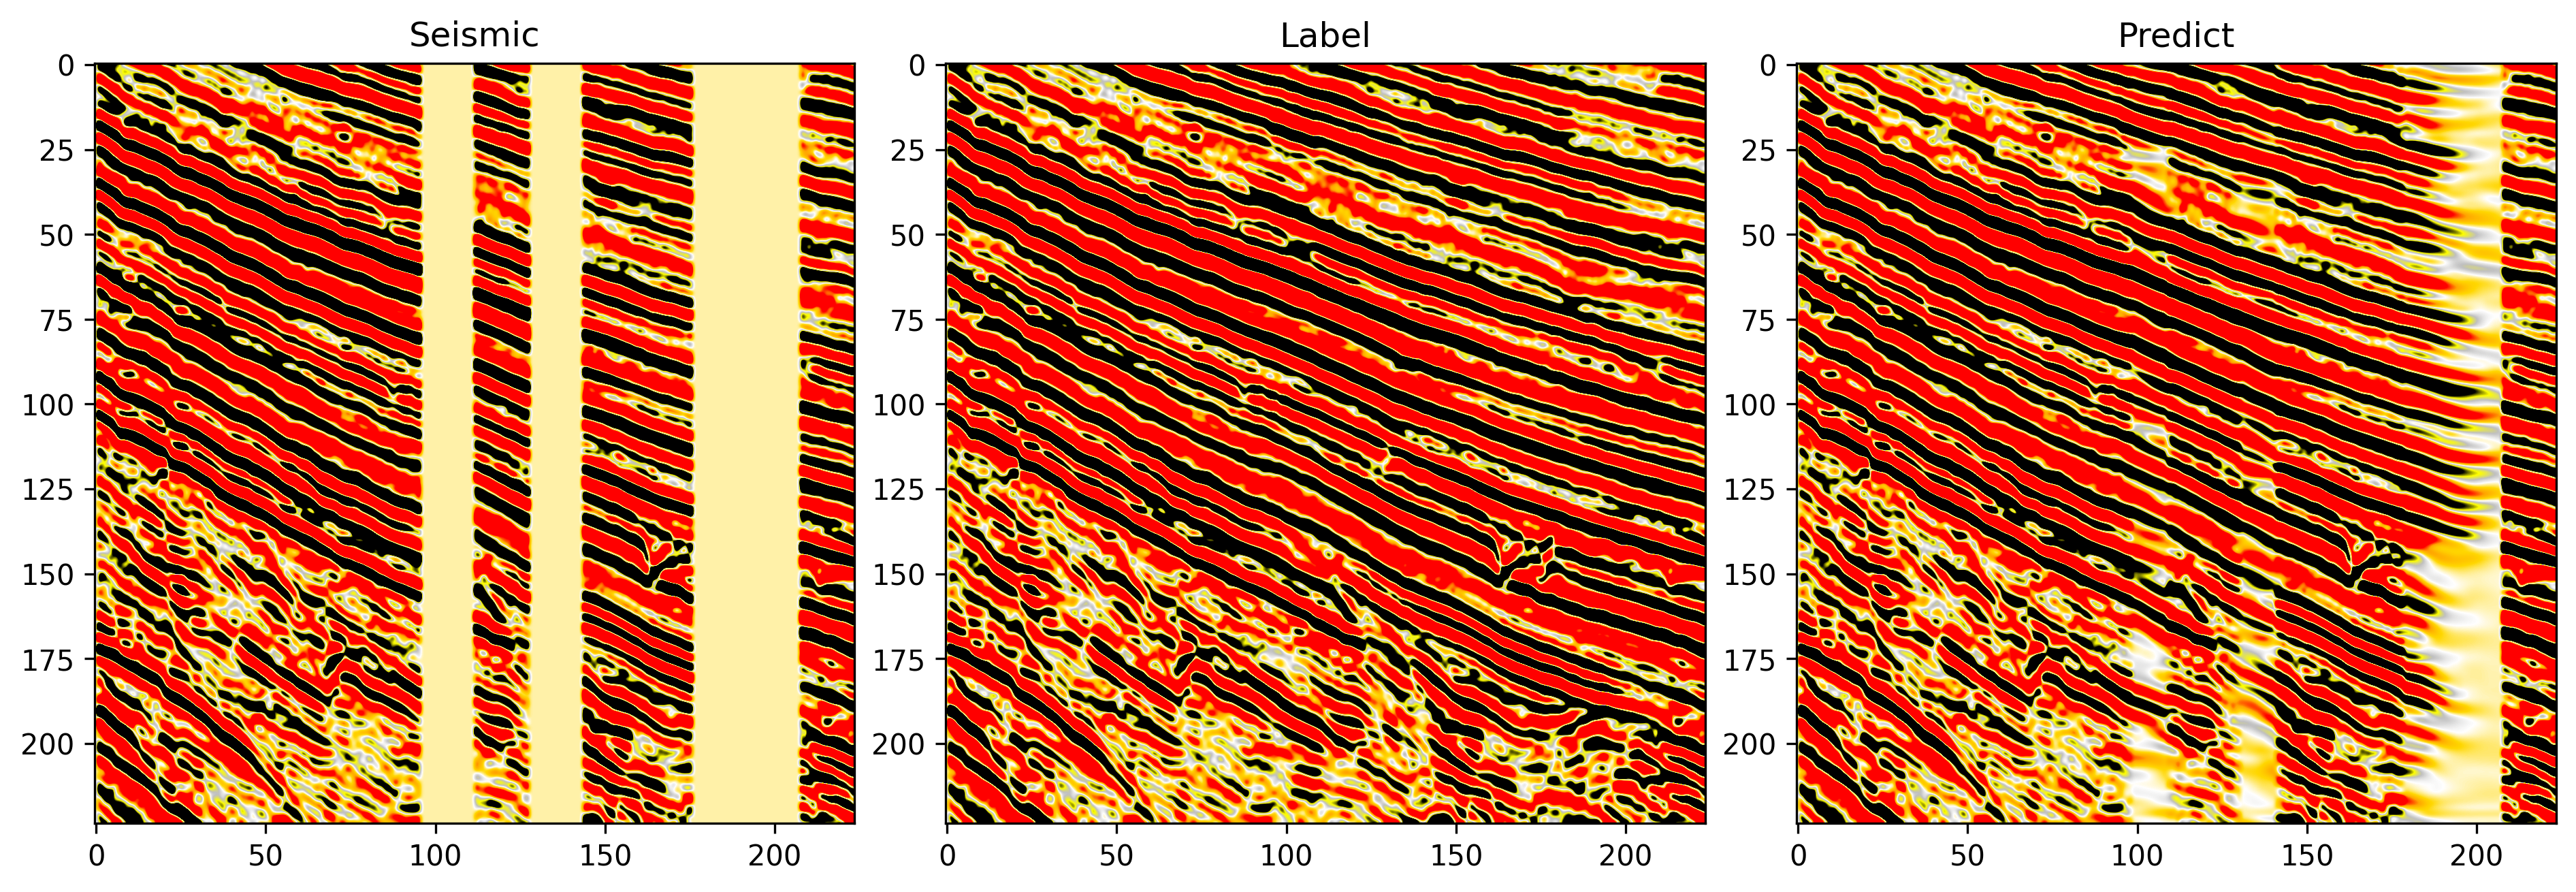

In [33]:
def run_one_image(img, model):
    color_list = ['#F19E9C','#EB5C56','#43972B','#FEE76B','#F3B677','#0082F4'] #seam
    cmapl = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    color_list = ['black','yellow','silver','white','gold','orange','red']
    cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    device = next(model.parameters()).device
    
    x = torch.tensor(img).to(device)
    x = x.unsqueeze(0)
    x = x.unsqueeze(0)
    model.eval()
    mask = model.generate_mask(x, 0.75)
    x_mask = x * mask
    pred = model(x_mask)[1]
    pred = pred * (1 - mask) + x_mask
    pred = pred.detach().cpu().squeeze(0).squeeze(0)
    # print(pred.shape)
    x_mask = x_mask.squeeze(0).squeeze(0).detach().cpu()
    # print(mask)
    # print(mask.shape)
    # print(mask.sum())
    
    figsize = np.array([25, 10]) * 0.5
    dpi = 300
    fig, axs = plt.subplots(1, 3, figsize=figsize, dpi=dpi, constrained_layout=True)
    axi = axs[0]
    axi.imshow(x_mask, cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Seismic")
    axi = axs[1]
    axi.imshow(img   , cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Label")
    axi = axs[2]
    axi.imshow(pred,   cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Predict")


data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Interpolation/'

dnum = np.random.randint(2000, 4000)
print(dnum)
d = np.fromfile(os.path.join(data_path, '%d.dat' % dnum), np.float32)
# d = np.fromfile(os.path.join(data_path, 'U%d.dat' % dnum), np.float32)
img_size = int(np.sqrt(d.size))
d = d.reshape((img_size, img_size))
# plt.imshow(d)
run_one_image(d, model_SFM)